In [ ]:
import numpy as np 
import pandas as pd

df=pd.read_parquet('Alzheimer MRI Disease Classification Dataset/Data/train-00000-of-00001-c08a401c53fe5312.parquet')
val_data=pd.read_parquet('Alzheimer MRI Disease Classification Dataset/Data/test-00000-of-00001-44110b9df98c5585.parquet')


: 

In [20]:
print(df.head(5))
print("*"*100)
print(val_data.head(5))
print("*"*100)
print(df.shape,val_data.shape)

                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
****************************************************************************************************
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
****************************************************************************************************
(5120, 2) (1280, 2)


In [ ]:
import cv2
import matplotlib.pyplot as plt

def convert_to_format(bytes_df):
    img_arr=np.frombuffer(bytes_df,dtype=np.uint8) 
    img=cv2.imdecode(img_arr,cv2.IMREAD_COLOR)    
    return img

images=[]

def get_img(df):
    images=[]
    for i in range(len(df)):
        inputt=df.iloc[i]['image']['bytes']
        cv_data=convert_to_format(inputt)
        images.append(cv_data)
    return images

images=get_img(df)

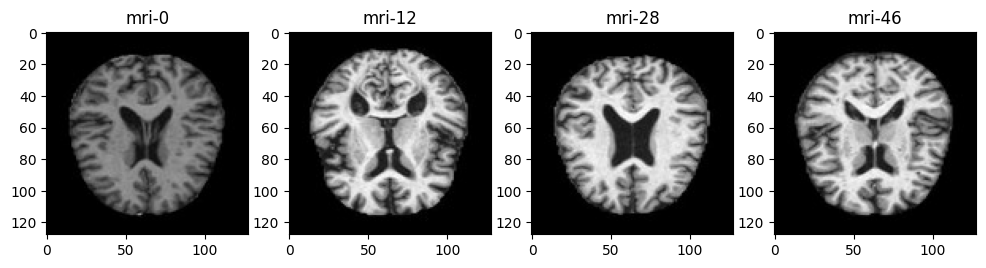

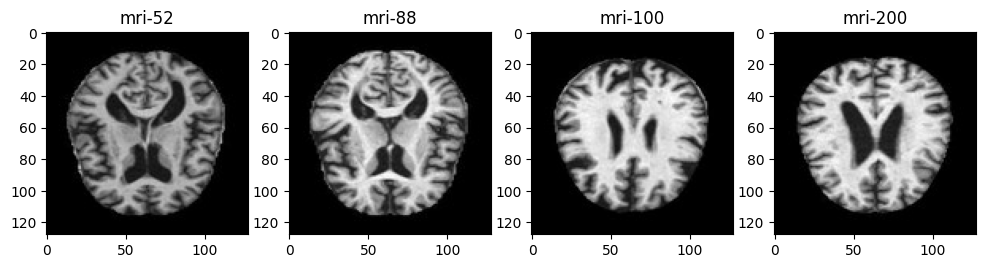

In [ ]:

plt.figure(figsize=(12,9))
plt.subplot(241)
plt.imshow(cv2.cvtColor(images[0],cv2.COLOR_BGR2RGB))
plt.title('mri-0')

plt.subplot(242)
plt.imshow(cv2.cvtColor(images[12],cv2.COLOR_BGR2RGB))
plt.title('mri-12')


plt.subplot(243)
plt.imshow(cv2.cvtColor(images[28],cv2.COLOR_BGR2RGB))
plt.title('mri-28')


plt.subplot(244)
plt.imshow(cv2.cvtColor(images[46],cv2.COLOR_BGR2RGB))
plt.title('mri-46')
plt.show() 

plt.figure(figsize=(12,9))
plt.subplot(241)
plt.imshow(cv2.cvtColor(images[52],cv2.COLOR_BGR2RGB))
plt.title('mri-52')

plt.subplot(242)
plt.imshow(cv2.cvtColor(images[88],cv2.COLOR_BGR2RGB))
plt.title('mri-88')


plt.subplot(243)
plt.imshow(cv2.cvtColor(images[100],cv2.COLOR_BGR2RGB))
plt.title('mri-100')

plt.subplot(244)
plt.imshow(cv2.cvtColor(images[200],cv2.COLOR_BGR2RGB))
plt.title('mri-200')
plt.show()


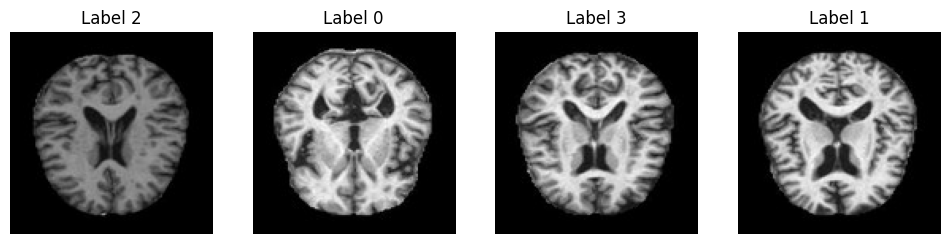

In [ ]:
def get_images_per_label(df):
    selected_images = {}  

    for i in range(len(df)):
        label = df.iloc[i]['label']  
        if label not in selected_images:  
            inputt = df.iloc[i]['image']['bytes']
            cv_data = convert_to_format(inputt)
            selected_images[label] = cv_data  
        if len(selected_images) == 4:  
            break

    return selected_images  

mri_images = get_images_per_label(df)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, (label, img) in enumerate(mri_images.items()):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Label {label}")
    axes[i].axis("off")
plt.show()

In [24]:
df['label'].value_counts()

,count
label,
2,2566
3,1781
0,724
1,49


In [ ]:
df_agu=df[df['label'].isin([0,1])]
df_other=df[df['label'].isin([2,3])]


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import io
from sklearn.model_selection import train_test_split

def load_and_preprocess_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('L')  
    img = img.resize((128, 128)) 
    img_array = np.array(img, dtype=np.float32) / 255.0 
    img_array = np.expand_dims(img_array, axis=-1)  
    return img_array

df_agu = df[df['label'].isin([0,1])].copy()
df_other = df[df['label'].isin([2,3])].copy()

df_other['image_arr'] = df_other['image'].apply(lambda img_dict: load_and_preprocess_image(img_dict['bytes']))

datagen = ImageDataGenerator(
    rotation_range=50, width_shift_range=0.3, height_shift_range=0.3,
    shear_range=0.4, zoom_range=0.6, horizontal_flip=True,fill_mode="nearest"
)

augmented_images = []
augmented_labels = []

label_counts = df_agu['label'].value_counts()
max_count = label_counts.max()
new_label_counts = label_counts.copy()

for index, row in df_agu.iterrows():
    image_bytes = row['image']['bytes']
    label = row['label']

    img_array = load_and_preprocess_image(image_bytes)
    img_array = np.expand_dims(img_array, axis=0)  

    current_count = new_label_counts[label]
    if label == 1:
        augment_count = max(500, max_count - current_count)
    elif label == 0:
        augment_count = max(200, max_count - current_count)
    else:
        augment_count = min(max_count - current_count, 20) if current_count < max_count else 0

    for _ in range(augment_count):
        aug_iter = datagen.flow(img_array, batch_size=1)
        aug_img = next(aug_iter)[0] 

        augmented_images.append(aug_img)
        augmented_labels.append(label)

        new_label_counts[label] += 1
        if new_label_counts[label] >= max_count:
            break


df_agu['image_arr'] = df_agu['image'].apply(lambda img_dict: load_and_preprocess_image(img_dict['bytes']))


df_agu_augmented = pd.DataFrame({'image_arr': augmented_images, 'label': augmented_labels})


df_final = pd.concat([df_other, df_agu[['image_arr', 'label']], df_agu_augmented], ignore_index=True)


print(f"Original dataset size: {len(df)}")
print(f"Augmented dataset size: {len(df_final)}")
print(df_final['label'].value_counts())


X = np.array(df_final['image_arr'].to_list(), dtype=np.float32)
y = np.array(df_final['label'])


y_onehot = tf.keras.utils.to_categorical(y, num_classes=4)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=len(X_train)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

print(f"Train Dataset: {X_train.shape}, Test Dataset: {X_test.shape}")


Original dataset size: 5120
Augmented dataset size: 6567
label
2    2566
3    1781
0    1448
1     772
Name: count, dtype: int64
Train Dataset: (5253, 128, 128, 1), Test Dataset: (1314, 128, 128, 1)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


classes = np.array([0, 1, 2, 3])


class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_final['label'])


class_weights = dict(enumerate(class_weights))

class_weights[1] *= 1.0 

print("Modified Class Weights:", class_weights)


Modified Class Weights: {0: np.float64(1.1338052486187846), 1: np.float64(2.1266191709844557), 2: np.float64(0.6398090413094311), 3: np.float64(0.9218135878719821)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


model = Sequential([
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), 
    Dense(4, activation='softmax')  
])


model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(train_dataset, validation_data=test_dataset, epochs=100,class_weight=class_weights)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


165/165 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.4610 - loss: 1.5584 - val_accuracy: 0.3904 - val_loss: 1.9941
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5560 - loss: 1.0445 - val_accuracy: 0.4855 - val_loss: 2.1163
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.6003 - loss: 0.9457 - val_accuracy: 0.4734 - val_loss: 1.6509
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6229 - loss: 0.9055 - val_accuracy: 0.5761 - val_loss: 0.9757
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.6642 - loss: 0.8221 - val_accuracy: 0.6416 - val_loss: 0.8612
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7016 - loss: 0.7412 - val_accuracy: 0.6910 - val_loss: 0.8079
Epoch 7/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7094 - loss: 0.6970 - val_accuracy: 0.6750 - val_loss: 0.8877
Epoch 8/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7534 - loss: 0.6193 - val_accurac

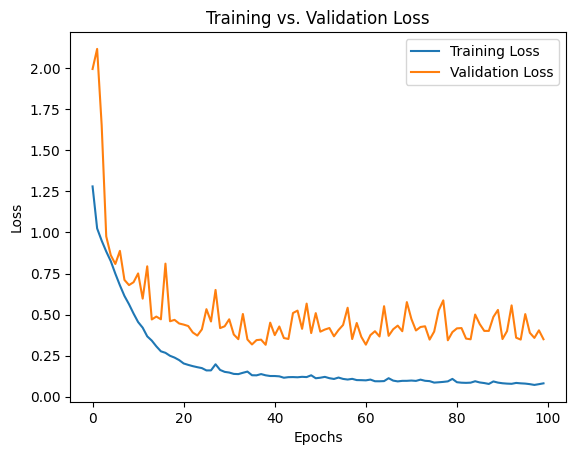

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_indices = np.argmax(model.predict(test_dataset), axis=1)


y_true_indices = np.argmax(y_test, axis=1)

print(classification_report(y_true_indices, y_pred_indices))


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       290
           1       0.77      0.84      0.80       155
           2       0.97      0.98      0.98       513
           3       0.98      0.97      0.97       356

    accuracy                           0.94      1314
   macro avg       0.91      0.91      0.91      1314
weighted avg       0.94      0.94      0.94      1314



In [ ]:
def preprocess_new_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('L')  
    img = img.resize((128, 128))  # Resize
    img_array = np.array(img, dtype=np.float32) / 255.0 
    img_array = np.expand_dims(img_array, axis=-1)  
    return img_array


val_data['image_arr'] = val_data['image'].apply(lambda img_dict: preprocess_new_image(img_dict['bytes']))

X_val = np.array(val_data['image_arr'].to_list(), dtype=np.float32)
y_val = np.array(val_data['label'])

y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)


val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_onehot)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

test_loss, test_acc = model.evaluate(val_dataset)
print(f"Test Accuracy: {test_acc:.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9677 - loss: 0.2831
Test Accuracy: 0.9727


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


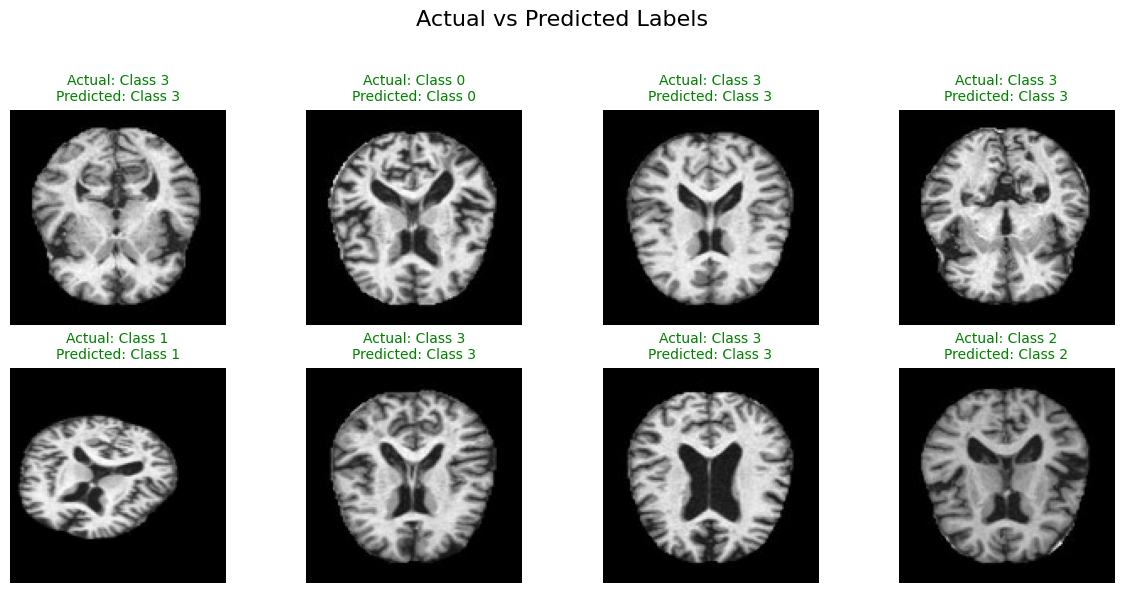

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

num_samples = 8
random_indices = random.sample(range(len(X_test)), num_samples)

random_images = X_test[random_indices]
actual_labels = np.argmax(y_test[random_indices], axis=1)  
predicted_labels = np.argmax(model.predict(random_images), axis=1)

class_names = ["Class 0", "Class 1", "Class 2", "Class 3"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Actual vs Predicted Labels", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = np.squeeze(random_images[i]) 
    ax.imshow(img, cmap="gray")  
    ax.axis("off")

    actual_class = class_names[actual_labels[i]]
    predicted_class = class_names[predicted_labels[i]]

    title_color = "green" if actual_labels[i] == predicted_labels[i] else "red"
    ax.set_title(f"Actual: {actual_class}\nPredicted: {predicted_class}", color=title_color, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
model.save('alzheimer_model.h5')